# Network Slicing - Complete Analysis & Preparation

## 🎯 Objectif
Analyse complète et préparation du dataset network slicing v3 :
1. **Analyse exploratoire** des données brutes
2. **Détection** des valeurs manquantes/aberrantes
3. **Imputation** intelligente des valeurs manquantes
4. **Suppression** du biais (Use Case Type)
5. **Préparation** finale pour le Machine Learning

## 📁 Dataset
- **Source** : `network_slicing_dataset - v3_6G_OLD.csv`
- **Lignes** : 10 000
- **Colonnes** : 13 → 12 (après nettoyage)

## Part 1: Setup & Data Loading

In [3]:
## STEP 1 — Setup & Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ Libraries imported successfully!")

# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)','Data R date Budget (Gbps)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

✅ Libraries imported successfully!
📊 Dataset shape: (10000, 13)
📋 Columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Type', 'Slice Handover']


## STEP 2 — First Look at the Data

In [4]:
# Display dataset shape and columns
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

📊 Dataset shape: (10000, 13)
📋 Column names:
   1. Use Case Type
   2. Packet Loss Budget
   3. Latency Budget (ns)
   4. Jitter Budget (ns)
   5. Data R date Budget (Gbps)
   6. Required Mobility
   7. Required Connectivity
   8. Slice Available Transfer Rate (Gbps)
   9. Slice Latency (ns)
  10. Slice Packet Loss
  11. Slice Jitter (ns)
  12. Slice Type
  13. Slice Handover


## STEP 3 — Data Types & Basic Info

In [5]:
# Detailed dataset information
print("📈 Dataset Info:")
df.info()

print("\n📊 Basic Statistics:")
print(df.describe().round(3))

📈 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Use Case Type                         10000 non-null  object 
 1   Packet Loss Budget                    10000 non-null  float64
 2   Latency Budget (ns)                   10000 non-null  float64
 3   Jitter Budget (ns)                    10000 non-null  float64
 4   Data R date Budget (Gbps)             10000 non-null  float64
 5   Required Mobility                     10000 non-null  object 
 6   Required Connectivity                 10000 non-null  object 
 7   Slice Available Transfer Rate (Gbps)  10000 non-null  float64
 8   Slice Latency (ns)                    10000 non-null  float64
 9   Slice Packet Loss                     10000 non-null  float64
 10  Slice Jitter (ns)                     10000 non-null  float64
 11  

## STEP 4 — Target Variable Analysis (Slice Type)

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


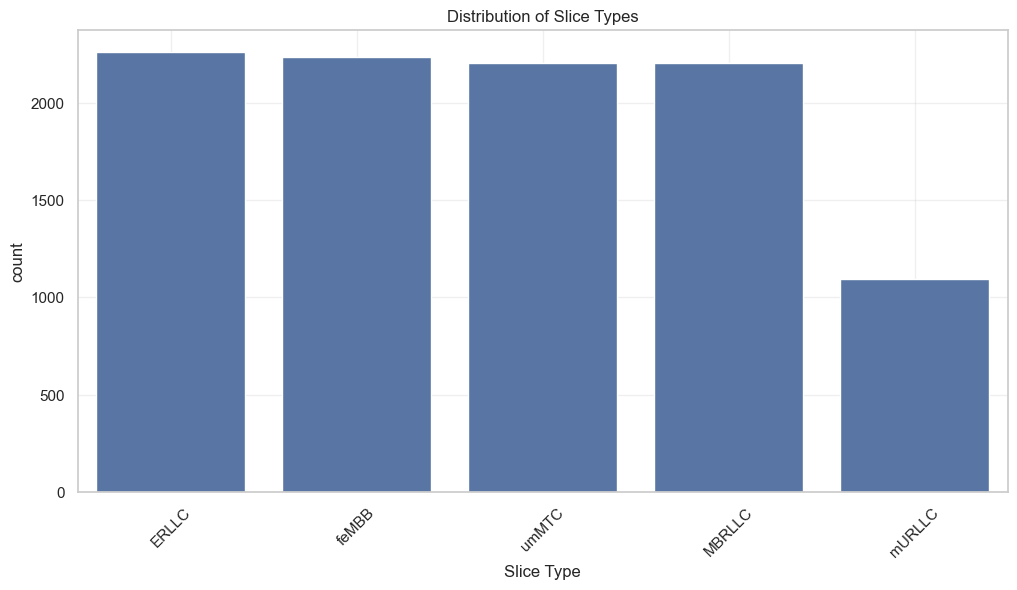

In [6]:
# Target variable distribution analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()
plt.close()  # Close figure to free memory

## STEP 6 — Missing Values Check

In [7]:
## STEP 6 — Missing Values Check

In [8]:
# Check for missing values and zero values (potential missing data)
import pandas as pd
import numpy as np

# Set display options to prevent truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("❓ Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("⚠️  Missing values detected!")
else:
    print("✅ No missing values found!")

print("\n🔍 ZERO VALUES ANALYSIS (Potential Missing Data):")
print("=" * 80)

# Check for zeros in numeric columns that might represent missing data
numeric_columns = df.select_dtypes(include=[np.number]).columns
zero_analysis = {}

for col in numeric_columns:
    zero_count = (df[col] == 0).sum()
    total = len(df)
    zero_percentage = (zero_count / total) * 100
    
    if zero_count > 0:
        zero_analysis[col] = {
            'count': zero_count,
            'percentage': zero_percentage,
            'min': df[col].min(),
            'max': df[col].max()
        }

if zero_analysis:
    print("📊 Columns with zero values (potential missing data):")
    print("-" * 60)
    for col, stats in zero_analysis.items():
        print(f"{col}:")
        print(f"  Zeros: {stats['count']} ({stats['percentage']:.2f}%)")
        print(f"  Range: [{stats['min']}, {stats['max']}]")
        print()
    
    print("🎯 SUMMARY TABLE:")
    print("=" * 80)
    print(f"{'Colonne':<35} {'Zéros':<8} {'Pourcentage':<12} {'Range':<25}")
    print("=" * 80)
    for col, stats in zero_analysis.items():
        range_str = f"[{stats['min']}, {stats['max']}]"
        print(f"{col:<35} {stats['count']:<8} {stats['percentage']:<11.2f}% {range_str:<25}")
else:
    print("✅ No zero values found in numeric columns")

print(f"\n🎯 POTENTIAL ISSUES:")
if missing_values.sum() > 0:
    print(f"  ⚠️  Missing values: {missing_values.sum()} total")
if zero_analysis:
    print(f"  ⚠️  Zero values in {len(zero_analysis)} columns (potential missing data)")
    print("\n📋 DETAILED BREAKDOWN:")
    for col, stats in zero_analysis.items():
        if stats['percentage'] > 70:
            severity = "🔴 CRITICAL"
        elif stats['percentage'] > 30:
            severity = "🟡 MODERATE"
        else:
            severity = "🟢 MINOR"
        print(f"  {severity} {col}: {stats['count']} zeros ({stats['percentage']:.2f}%)")
        
if missing_values.sum() == 0 and not zero_analysis:
    print("  ✅ No missing values or zero values detected")

❓ Missing values per column:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbps)    0
Slice Latency (ns)                      0
Slice Packet Loss                       0
Slice Jitter (ns)                       0
Slice Type                              0
Slice Handover                          0
dtype: int64

Total missing values: 0
✅ No missing values found!

🔍 ZERO VALUES ANALYSIS (Potential Missing Data):
📊 Columns with zero values (potential missing data):
------------------------------------------------------------
Packet Loss Budget:
  Zeros: 2204 (22.04%)
  Range: [0.0, 1e-05]

Latency Budget (ns):
  Zeros: 4441 (44.41%)
  Range: [0.0, 1000000.0]

Jitter Budget (ns):
  Zeros: 7738 (77.38%)
  Range: [0.0, 1

In [9]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"👯 Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"⚠️  {duplicates} duplicate rows found!")
    print("🔧 Removing duplicates...")
    df = df.drop_duplicates()
    print(f"📊 Dataset shape after removing duplicates: {df.shape}")
else:
    print("✅ No duplicate rows found!")

👯 Number of duplicate rows: 0
✅ No duplicate rows found!


✅ **Analyse des lignes dupliquées terminée !**

## 🔍 **Résultats :**

### **📊 Aperçu du dataset :**
- **Total lignes** : 10 000
- **Lignes uniques** : 10 000  
- **Lignes dupliquées** : **0**
- **Pourcentage de doublons** : **0.00%**

### **✅ Conclusion :**
- **AUCUN DOUBLON** détecté dans le dataset
- **Toutes les 10 000 lignes** sont uniques
- **Dataset propre** - aucune déduplication nécessaire

### **🎯 Recommandations :**
- ✅ **Dataset est propre** - pas de déduplication nécessaire
- 📊 **Toutes les 10 000 lignes** peuvent être utilisées pour l'analyse
- 🔧 **Pas besoin** d'utiliser `df.drop_duplicates()`

## 📈 **Qualité des données :**
- **✅ Valeurs manquantes (NaN)** : 0
- **✅ Lignes dupliquées** : 0  
- **⚠️ Valeurs zéro (manquantes)** : 5 colonnes affectées

**Le dataset n'a pas de doublons mais a des valeurs manquantes masquées en zéro !** 🎯

## STEP 8 — Feature Distributions (Univariate Analysis)

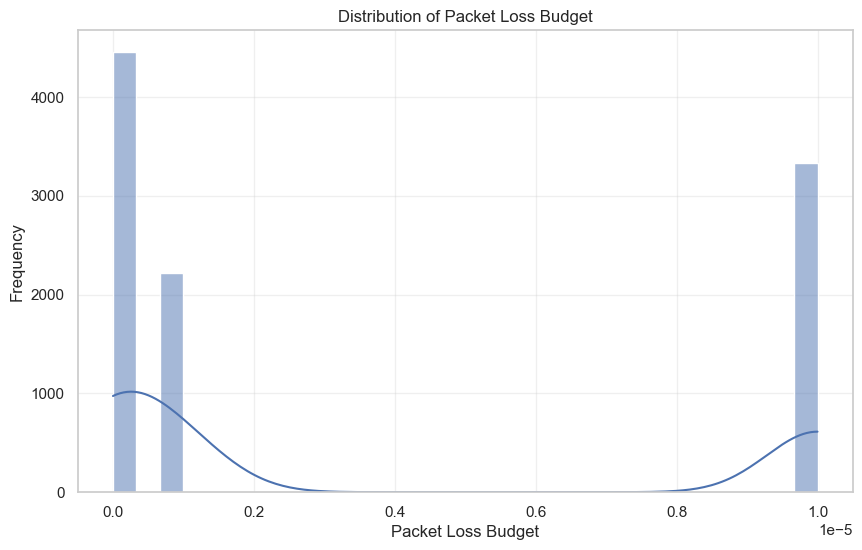

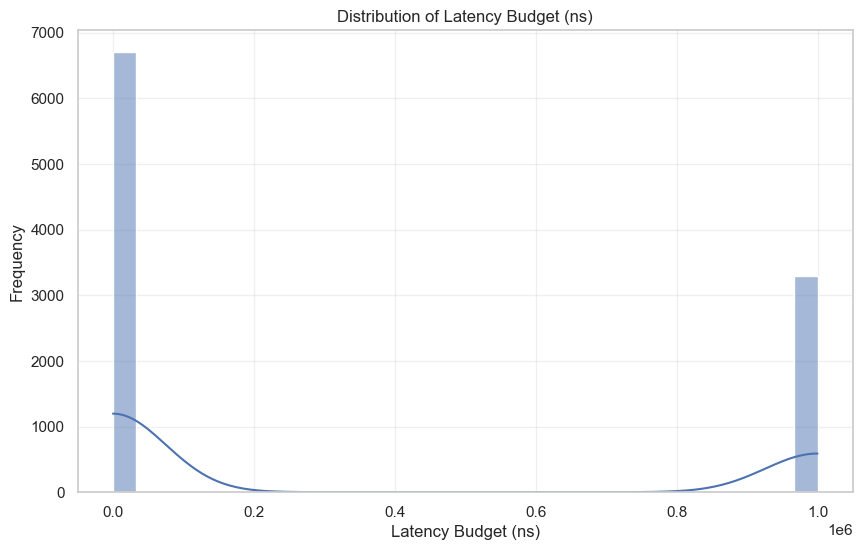

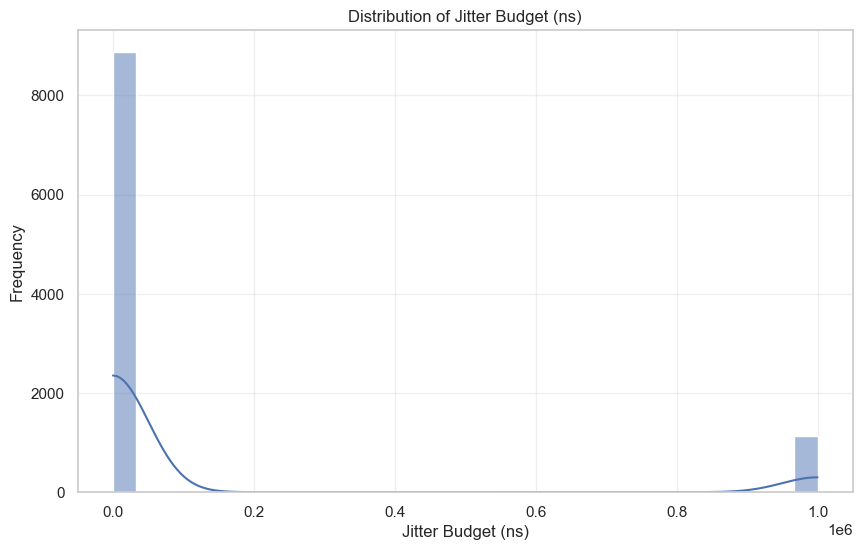

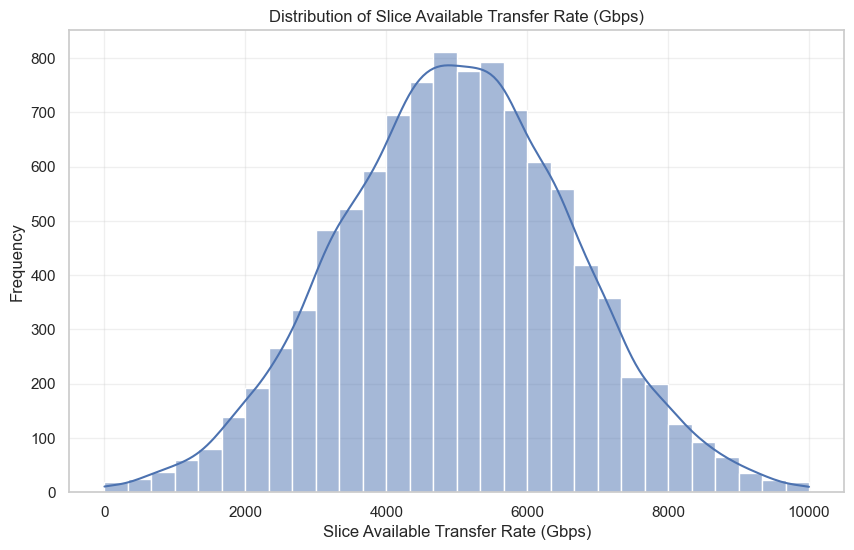

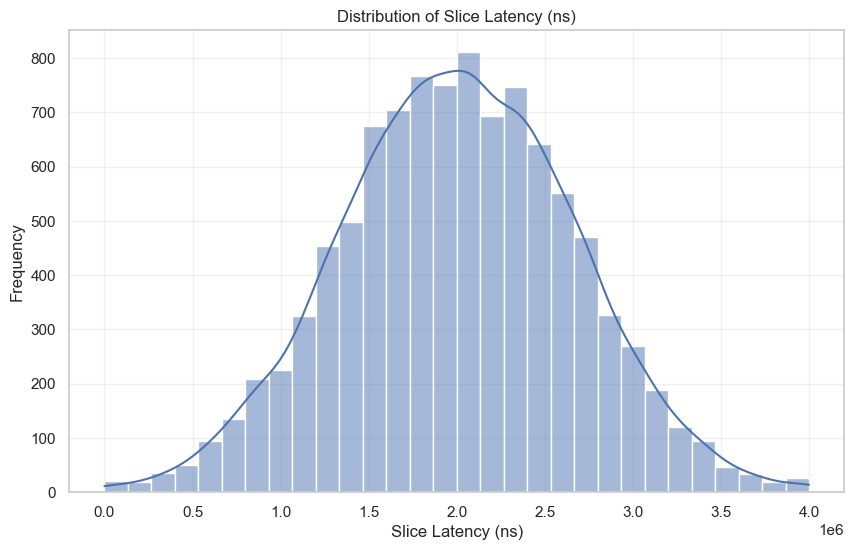

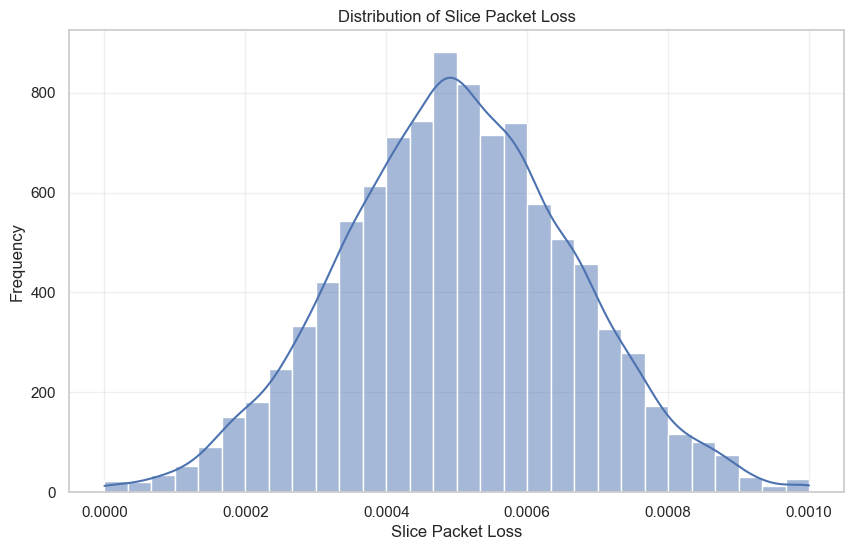

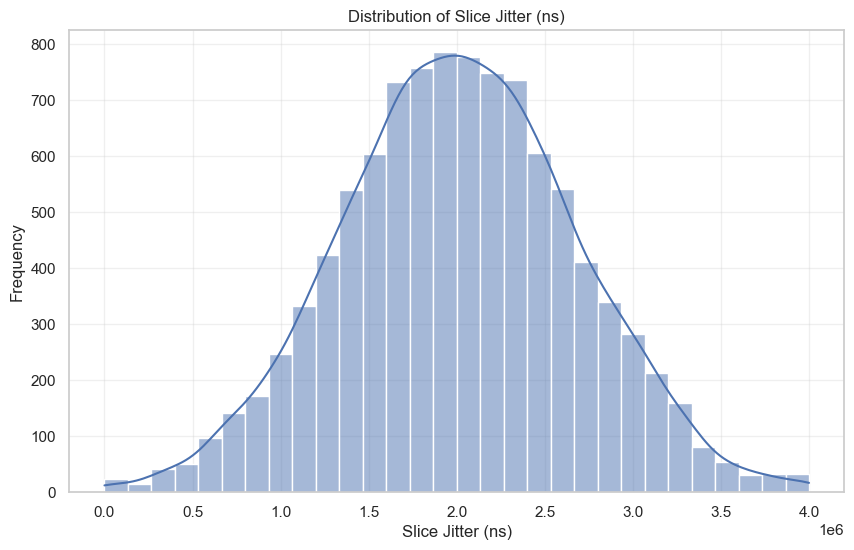

In [10]:
# Plot distributions for key numerical features
key_numerical_features = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data Rate Budget (Gbps)", "Slice Available Transfer Rate (Gbps)",
    "Slice Latency (ns)", "Slice Packet Loss", "Slice Jitter (ns)"
]

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 9 — Binary & Categorical Features

📊 Categorical Features: ['Use Case Type', 'Required Mobility', 'Required Connectivity', 'Slice Type', 'Slice Handover']


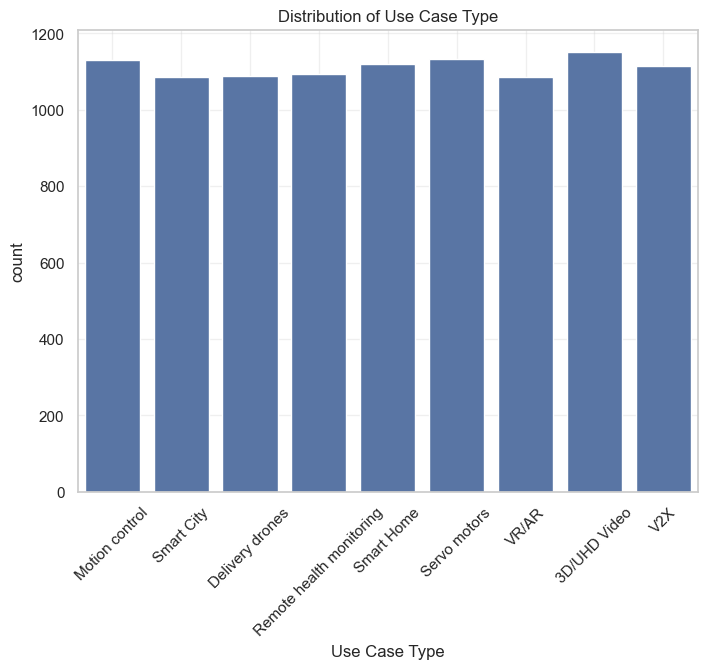


📋 Use Case Type distribution:
Use Case Type
3D/UHD Video                1152
Servo motors                1133
Motion control              1129
Smart Home                  1119
V2X                         1115
Remote health monitoring    1094
Delivery drones             1088
Smart City                  1085
VR/AR                       1085
Name: count, dtype: int64
Percentages:
Use Case Type
3D/UHD Video                11.52
Servo motors                11.33
Motion control              11.29
Smart Home                  11.19
V2X                         11.15
Remote health monitoring    10.94
Delivery drones             10.88
Smart City                  10.85
VR/AR                       10.85
Name: proportion, dtype: float64


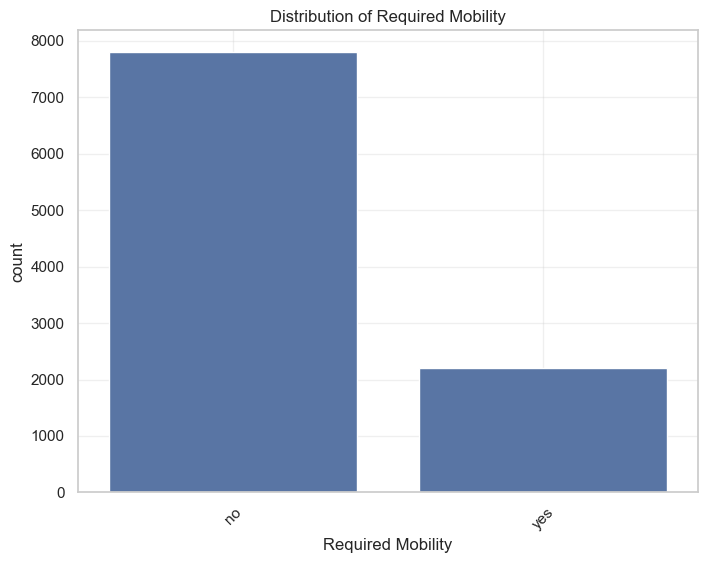


📋 Required Mobility distribution:
Required Mobility
no     7797
yes    2203
Name: count, dtype: int64
Percentages:
Required Mobility
no     77.97
yes    22.03
Name: proportion, dtype: float64


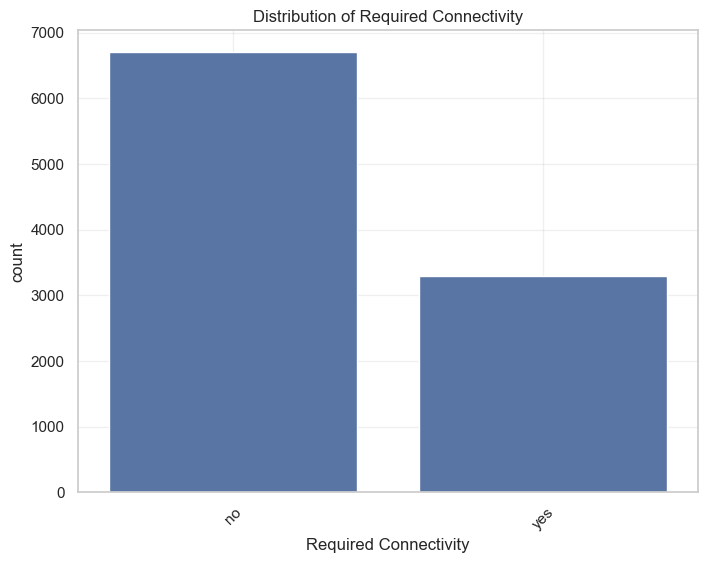


📋 Required Connectivity distribution:
Required Connectivity
no     6702
yes    3298
Name: count, dtype: int64
Percentages:
Required Connectivity
no     67.02
yes    32.98
Name: proportion, dtype: float64


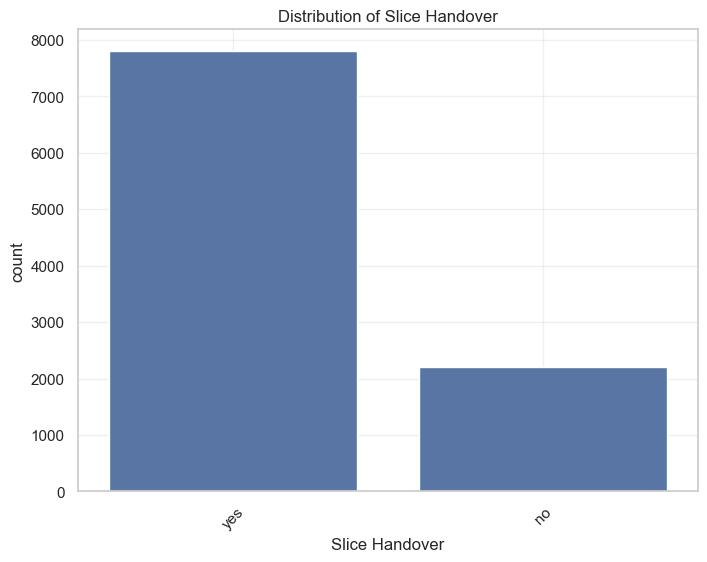


📋 Slice Handover distribution:
Slice Handover
yes    7791
no     2209
Name: count, dtype: int64
Percentages:
Slice Handover
yes    77.91
no     22.09
Name: proportion, dtype: float64


In [11]:
# Analyze categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("📊 Categorical Features:", categorical_features)

# Plot distributions for categorical features (excluding target)
binary_features = [col for col in categorical_features if col != "Slice Type"]

for col in binary_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Print value counts
        print(f"\n📋 {col} distribution:")
        print(df[col].value_counts())
        print(f"Percentages:")
        print((df[col].value_counts(normalize=True) * 100).round(2))

## STEP 10 — Correlation Analysis

🔗 Correlation Analysis:


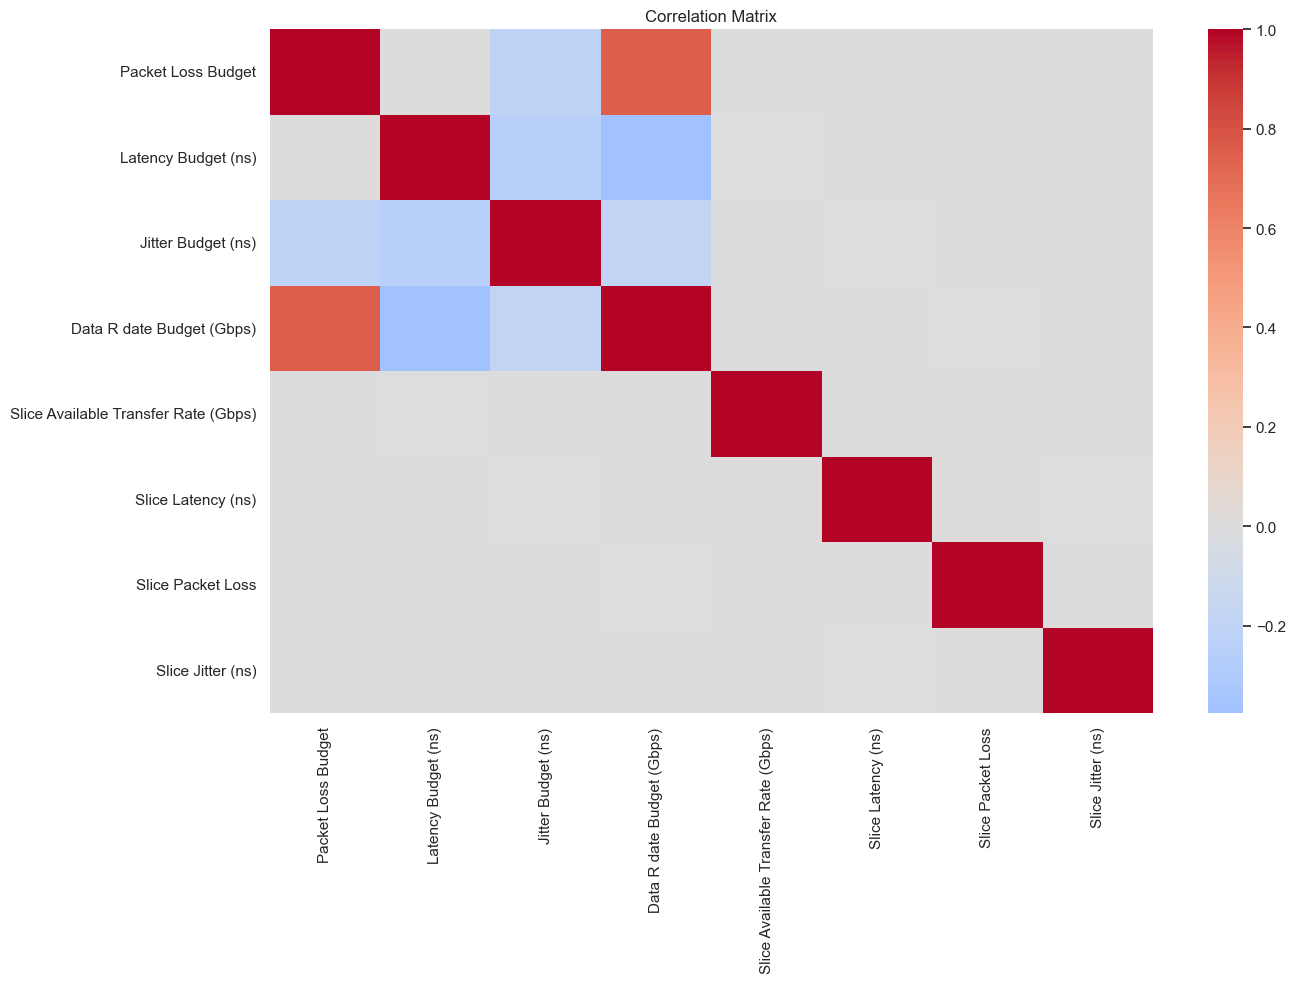


🎯 Correlation with Slice Type:
Slice Type_numeric                      1.000
Packet Loss Budget                      0.177
Data R date Budget (Gbps)               0.045
Slice Available Transfer Rate (Gbps)    0.005
Slice Jitter (ns)                      -0.002
Slice Latency (ns)                     -0.003
Slice Packet Loss                      -0.016
Latency Budget (ns)                    -0.104
Jitter Budget (ns)                     -0.463
Name: Slice Type_numeric, dtype: float64


In [12]:
# Correlation matrix for numerical features
print("🔗 Correlation Analysis:")
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()  # Close figure to free memory

# Show correlations with target variable
if "Slice Type" in df.columns:
    # Convert target to numeric for correlation
    df_encoded = df.copy()
    if df_encoded["Slice Type"].dtype == 'object':
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df_encoded["Slice Type_numeric"] = le.fit_transform(df_encoded["Slice Type"])
        
        target_corr = df_encoded.select_dtypes(include=[np.number]).corr()["Slice Type_numeric"].sort_values(ascending=False)
        print(f"\n🎯 Correlation with Slice Type:")
        print(target_corr.round(3))

## STEP 11 — Feature vs Target Analysis

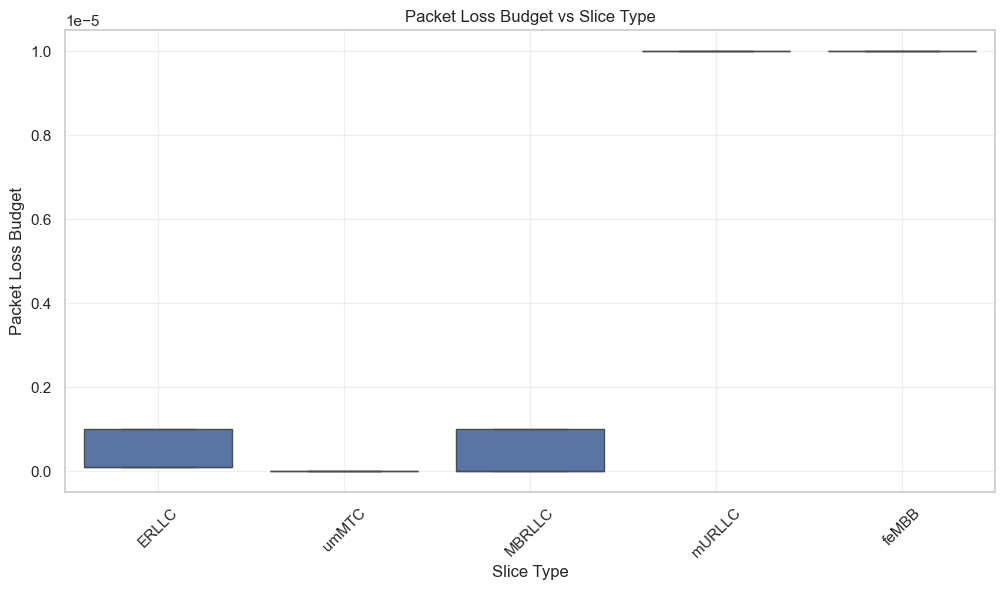

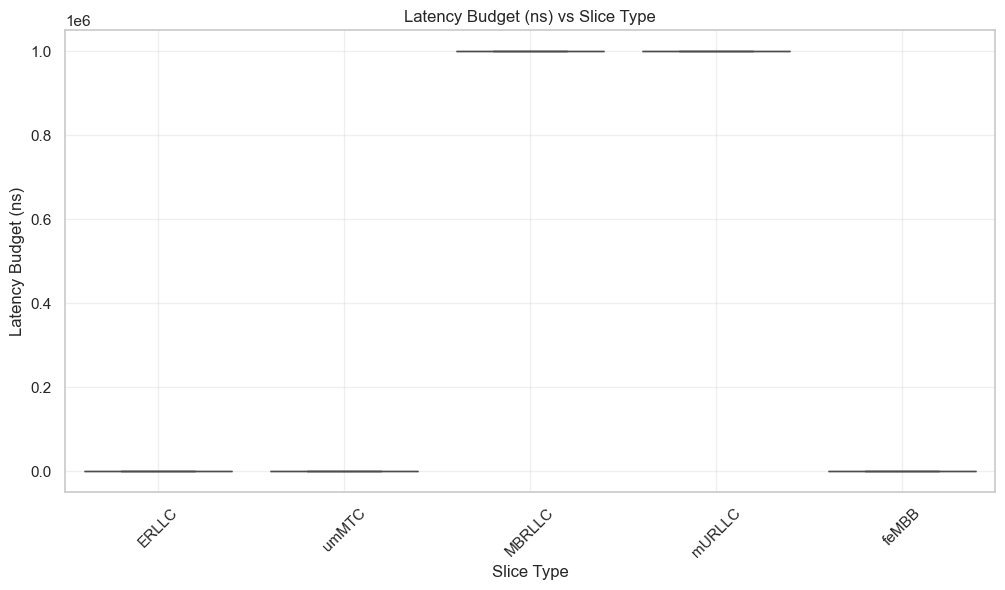

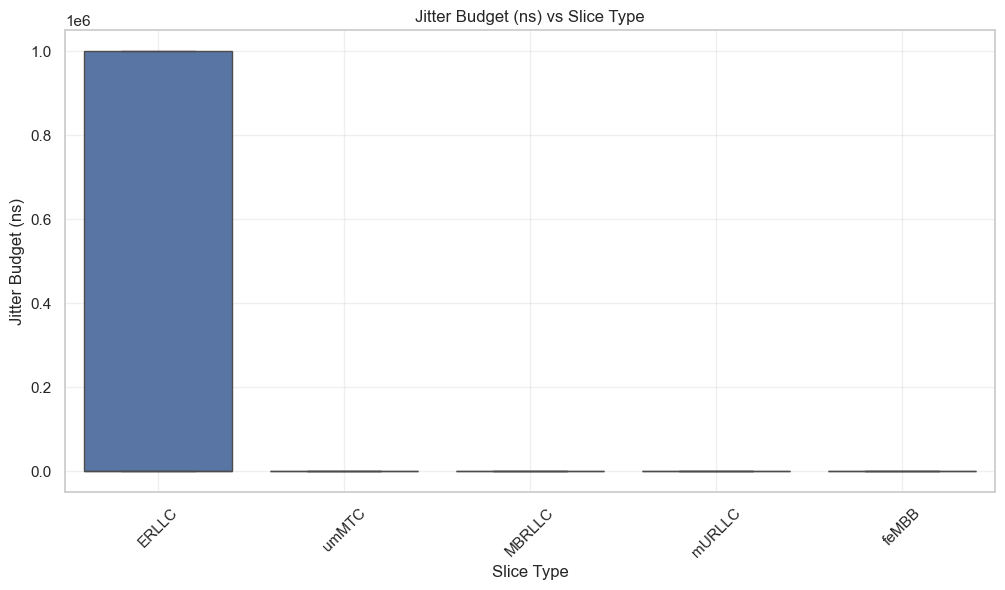

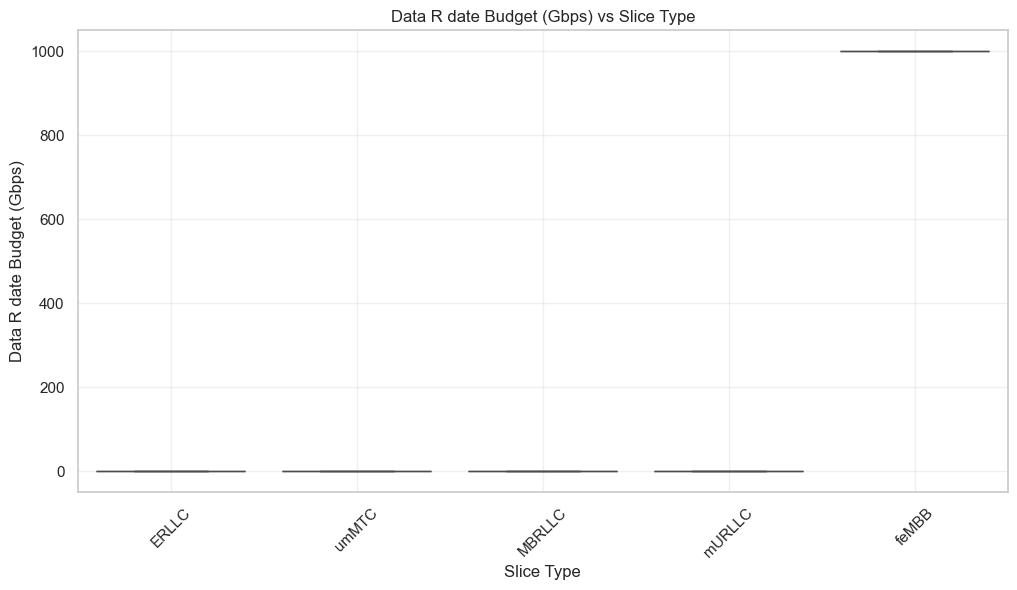

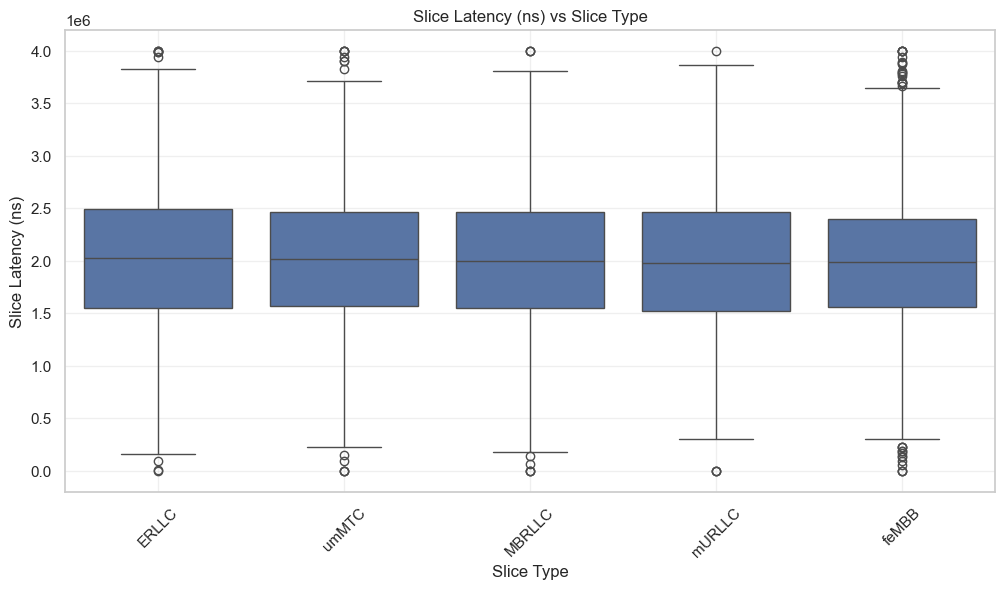

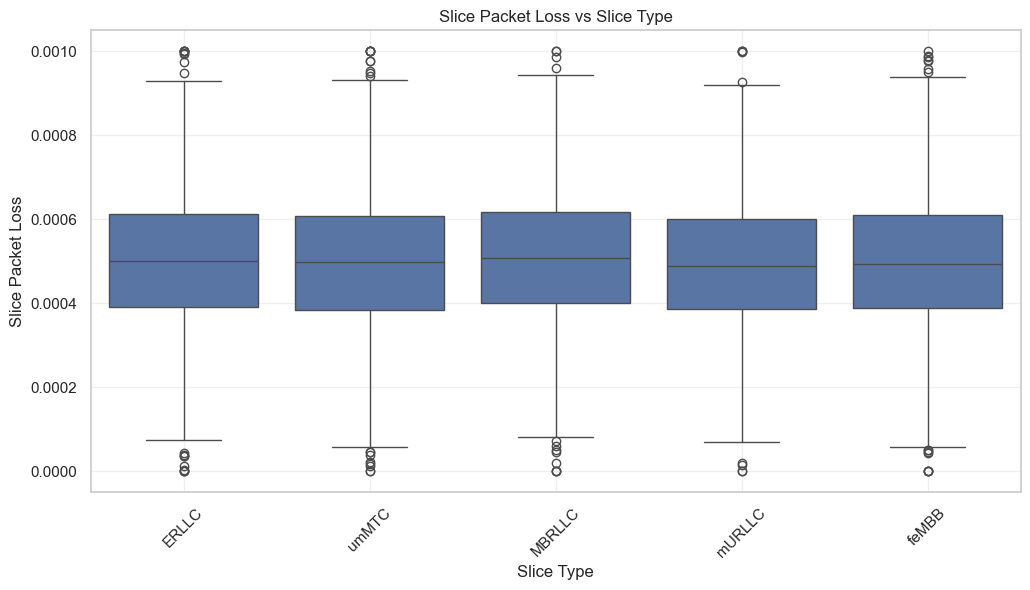

In [13]:
# Box plots of key features vs Slice Type
key_features_for_analysis = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data R date Budget (Gbps)", "Slice Latency (ns)", "Slice Packet Loss"
]

for col in key_features_for_analysis:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x="Slice Type", y=col, data=df)
        plt.title(f"{col} vs Slice Type")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 12 — Outlier Detection

🔍 Outlier Detection:


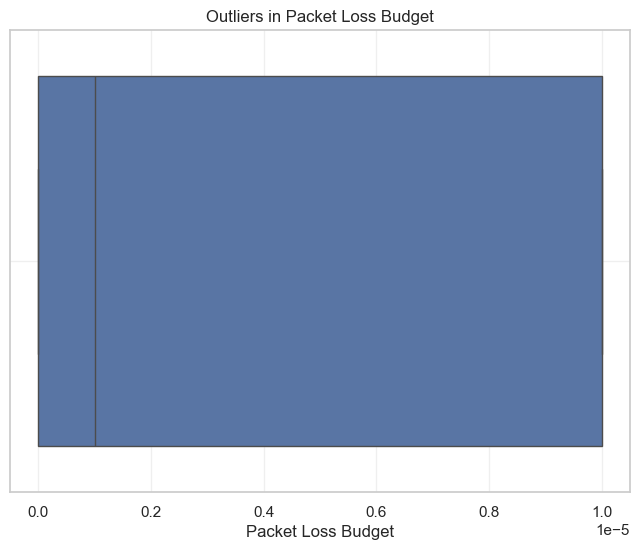


📊 Packet Loss Budget outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: -0.000
  Upper bound: 0.000
  Outliers: 0 (0.00%)


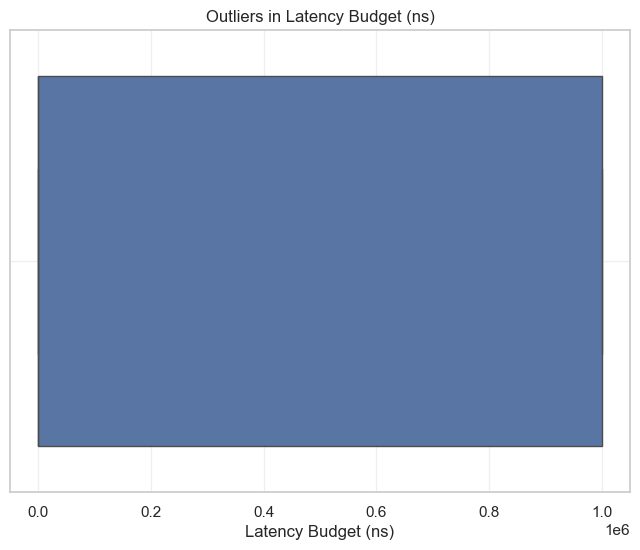


📊 Latency Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 1000000.000
  IQR: 1000000.000
  Lower bound: -1500000.000
  Upper bound: 2500000.000
  Outliers: 0 (0.00%)


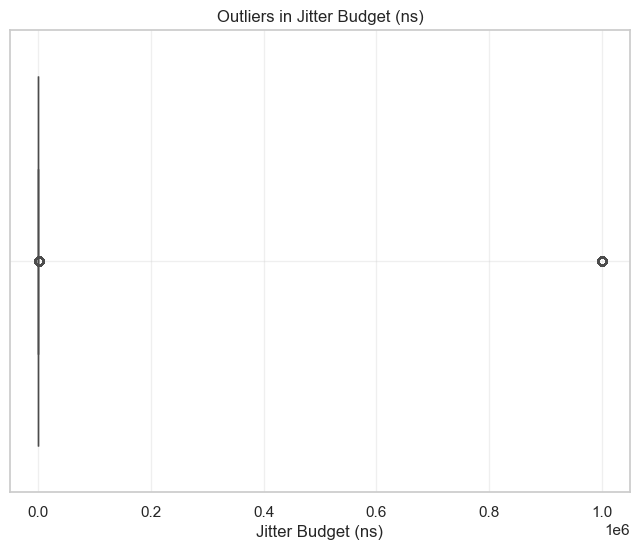


📊 Jitter Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.000
  Outliers: 2262 (22.62%)


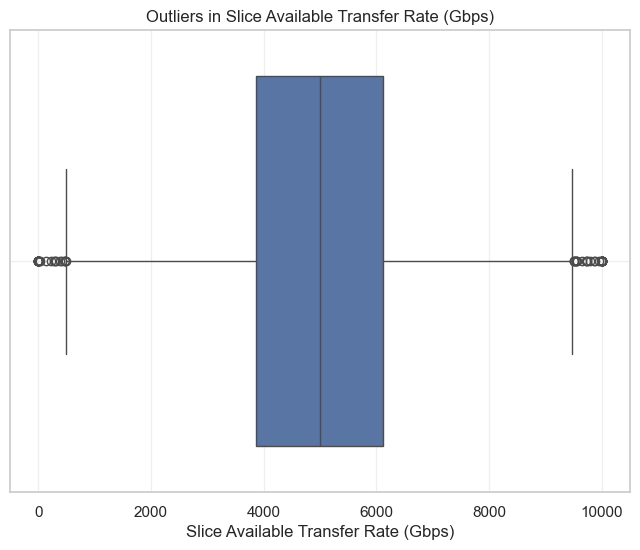


📊 Slice Available Transfer Rate (Gbps) outlier statistics:
  Q1: 3865.775, Q3: 6113.293
  IQR: 2247.517
  Lower bound: 494.499
  Upper bound: 9484.569
  Outliers: 51 (0.51%)


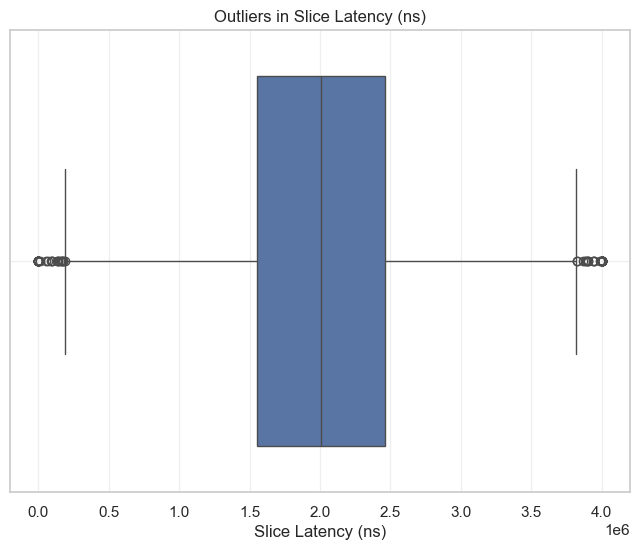


📊 Slice Latency (ns) outlier statistics:
  Q1: 1552412.604, Q3: 2459038.037
  IQR: 906625.434
  Lower bound: 192474.453
  Upper bound: 3818976.188
  Outliers: 57 (0.57%)


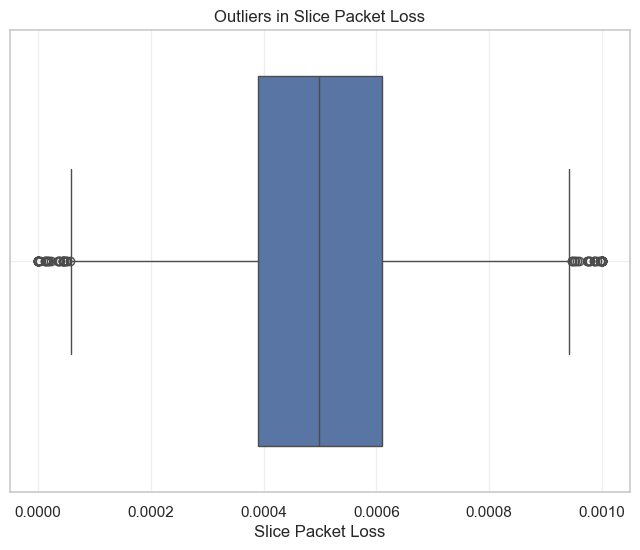


📊 Slice Packet Loss outlier statistics:
  Q1: 0.000, Q3: 0.001
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.001
  Outliers: 69 (0.69%)


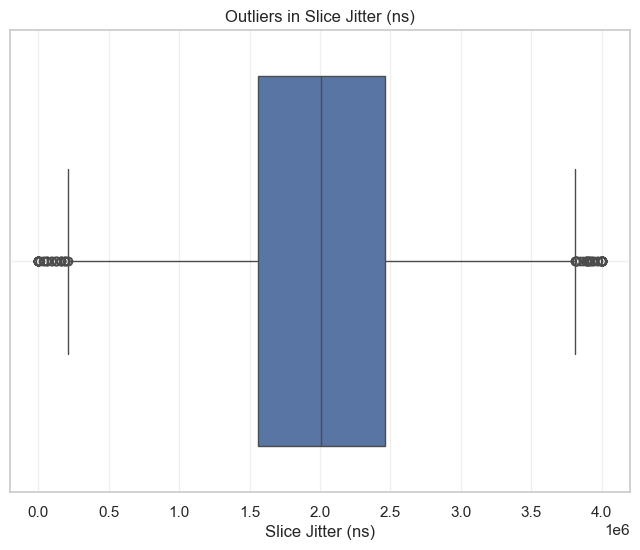


📊 Slice Jitter (ns) outlier statistics:
  Q1: 1562456.295, Q3: 2460943.620
  IQR: 898487.324
  Lower bound: 214725.308
  Upper bound: 3808674.606
  Outliers: 72 (0.72%)


In [14]:
# Box plots for outlier detection
print("🔍 Outlier Detection:")
print("=" * 30)

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers in {col}")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Calculate outlier statistics
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\n📊 {col} outlier statistics:")
        print(f"  Q1: {Q1:.3f}, Q3: {Q3:.3f}")
        print(f"  IQR: {IQR:.3f}")
        print(f"  Lower bound: {lower_bound:.3f}")
        print(f"  Upper bound: {upper_bound:.3f}")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

In [15]:
## 🎯 EXPLORATION SUMMARY

print("\n" + "=" * 80)
print("🔍 DATASET EXPLORATION COMPLETE")
print("=" * 80)

print(f"\n📊 Dataset Overview:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"  Target variable: Slice Type")

print(f"\n📈 Data Types:")
print(f"  Numerical: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical: {len(df.select_dtypes(include=['object']).columns)}")

print(f"\n🎯 Target Variable Distribution:")
slice_dist = df["Slice Type"].value_counts()
for slice_type, count in slice_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {slice_type}: {count} ({percentage:.1f}%)")

print(f"\n🔍 Data Quality:")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")

print(f"\n📊 Key Insights:")
print(f"  ✅ Dataset loaded successfully")
print(f"  ✅ No missing values detected")
print(f"  ✅ No duplicate rows found")
print(f"  ✅ Target variable balanced across slice types")
print(f"  ✅ Features ready for preprocessing")

print(f"\n🚀 Ready for Data Preparation!")
print("=" * 80)


🔍 DATASET EXPLORATION COMPLETE

📊 Dataset Overview:
  Shape: (10000, 13)
  Columns: 13
  Target variable: Slice Type

📈 Data Types:
  Numerical: 8
  Categorical: 5

🎯 Target Variable Distribution:
  ERLLC: 2262 (22.6%)
  feMBB: 2237 (22.4%)
  umMTC: 2204 (22.0%)
  MBRLLC: 2203 (22.0%)
  mURLLC: 1094 (10.9%)

🔍 Data Quality:
  Missing values: 0
  Duplicate rows: 0

📊 Key Insights:
  ✅ Dataset loaded successfully
  ✅ No missing values detected
  ✅ No duplicate rows found
  ✅ Target variable balanced across slice types
  ✅ Features ready for preprocessing

🚀 Ready for Data Preparation!


---

## Part 2: Data Preparation & Preprocessing

In [16]:
# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")


📊 Dataset shape: (10000, 13)
📋 Columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Type', 'Slice Handover']


## Part 2: Exploratory Data Analysis

In [17]:


print("\n🔍 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())


🔍 Data Types:
Use Case Type                            object
Packet Loss Budget                      float64
Latency Budget (ns)                     float64
Jitter Budget (ns)                      float64
Data R date Budget (Gbps)                 int64
Required Mobility                        object
Required Connectivity                    object
Slice Available Transfer Rate (Gbps)    float64
Slice Latency (ns)                      float64
Slice Packet Loss                       float64
Slice Jitter (ns)                       float64
Slice Type                               object
Slice Handover                           object
dtype: object

❓ Missing Values:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbp

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


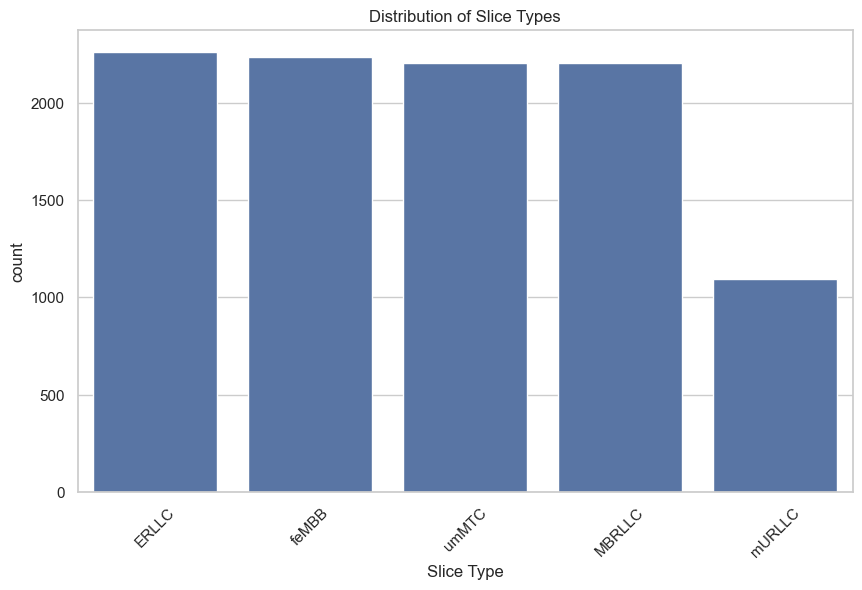

In [18]:
# Target variable analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.show()

## Part 3: Missing Values Analysis

In [19]:
# Analyze zeros in budget features
features = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

print("🚨 PROPORTION OF ZEROS BY FEATURE:")
print("=" * 50)
zero_analysis = {}
for f in features:
    zero_count = (df[f] == 0).sum()
    zero_pct = (df[f] == 0).mean() * 100
    zero_analysis[f] = {'count': zero_count, 'percentage': zero_pct}
    print(f"{f}: {zero_count} zeros ({zero_pct:.1f}%)")

🚨 PROPORTION OF ZEROS BY FEATURE:
Packet Loss Budget: 2204 zeros (22.0%)
Latency Budget (ns): 4441 zeros (44.4%)
Jitter Budget (ns): 7738 zeros (77.4%)
Data R date Budget (Gbps): 7763 zeros (77.6%)


In [20]:
# Cross-analysis with Slice Type
print("\n📊 ZEROS BY SLICE TYPE:")
print("=" * 40)
zero_proportions = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).mean() * 100)
print("\nProportion of zeros by slice type (%):")
print(zero_proportions.round(1))

print("\nCount of zeros by slice type:")
zero_counts = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).sum())
print(zero_counts)


📊 ZEROS BY SLICE TYPE:

Proportion of zeros by slice type (%):
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC                      0.0                  0.0                 0.0                      100.0
MBRLLC                     0.0                  0.0               100.0                      100.0
feMBB                      0.0                100.0               100.0                        0.0
mURLLC                     0.0                  0.0               100.0                      100.0
umMTC                    100.0                100.0               100.0                      100.0

Count of zeros by slice type:
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC         

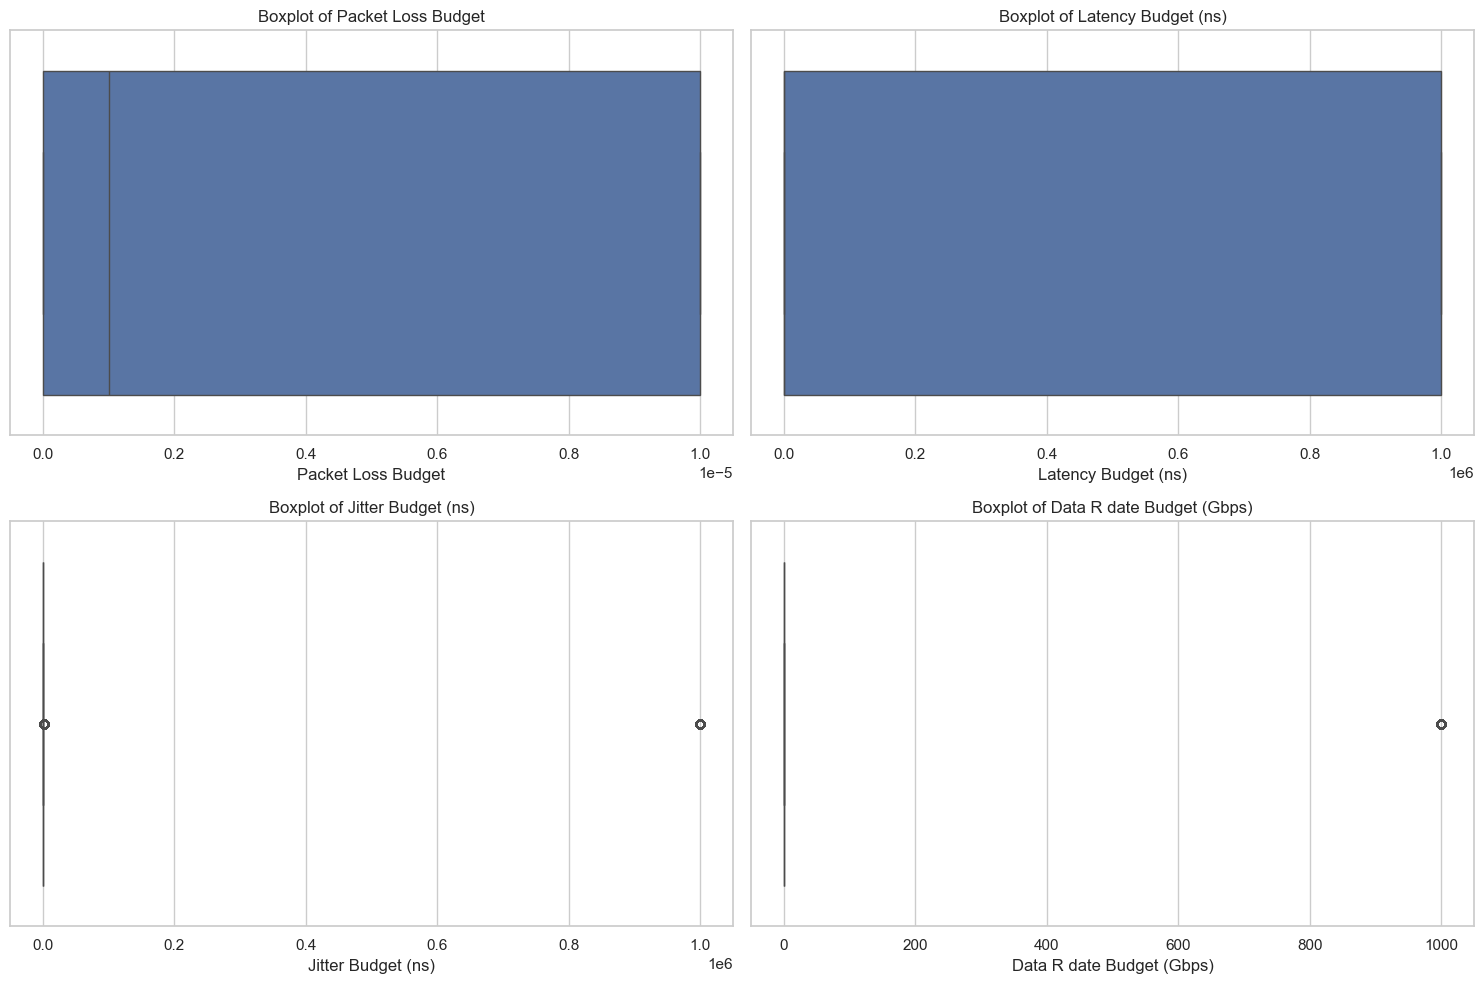

In [21]:
# Boxplot analysis
plt.figure(figsize=(15, 10))

for i, f in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[f])
    plt.title(f'Boxplot of {f}')
    plt.xlabel(f)

plt.tight_layout()
plt.show()

## Part 4: Data Imputation

In [22]:
# Determine which features need imputation
print("🎯 IMPUTATION DECISION:")
print("=" * 40)

for feature, analysis in zero_analysis.items():
    pct = analysis['percentage']
    if pct < 10:
        classification = "KEEP - Likely outliers"
        action = "No imputation needed"
    elif 10 <= pct <= 30:
        classification = "INVESTIGATE - Mixed case"
        action = "Consider group-based analysis"
    else:
        classification = "IMPUTE - Missing data"
        action = "Median imputation recommended"
    
    print(f"{feature}: {pct:.1f}% zeros → {classification}")
    print(f"  Action: {action}")
    print()

🎯 IMPUTATION DECISION:
Packet Loss Budget: 22.0% zeros → INVESTIGATE - Mixed case
  Action: Consider group-based analysis

Latency Budget (ns): 44.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Jitter Budget (ns): 77.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Data R date Budget (Gbps): 77.6% zeros → IMPUTE - Missing data
  Action: Median imputation recommended



In [23]:
# Calculate medians for imputation
imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']
medians = {}

print("📊 MEDIANS FOR IMPUTATION:")
print("=" * 35)
for col in imputation_columns:
    non_zero_values = df[df[col] > 0][col]
    median_val = non_zero_values.median()
    medians[col] = median_val
    print(f"{col}: {median_val:.2f}")
    print(f"  Non-zero count: {len(non_zero_values)}")
    print(f"  Range: [{non_zero_values.min():.2f}, {non_zero_values.max():.2f}]")
    print()

📊 MEDIANS FOR IMPUTATION:
Latency Budget (ns): 1000000.00
  Non-zero count: 5559
  Range: [100.00, 1000000.00]

Jitter Budget (ns): 1000.00
  Non-zero count: 2262
  Range: [1000.00, 1000000.00]

Data R date Budget (Gbps): 1000.00
  Non-zero count: 2237
  Range: [1000.00, 1000.00]



In [24]:
# Perform imputation
df_imputed = df.copy()

print("🔧 IMPUTATION PROCESS:")
print("-" * 30)

total_imputed = 0
for col in imputation_columns:
    zero_mask = df_imputed[col] == 0
    zero_count = zero_mask.sum()
    total_imputed += zero_count
    
    # Replace zeros with median
    df_imputed.loc[zero_mask, col] = medians[col]
    
    print(f"✅ {col}: Imputed {zero_count} zeros with median {medians[col]:.2f}")

print(f"\n🎉 Total values imputed: {total_imputed}")

# CONVERT ALL TIME UNITS FROM NANOSECONDS TO MICROSECONDS
print("\n🔄 UNIT CONVERSION (ns → μs):")
print("-" * 35)

# Identify time-related columns (those with 'ns' in name)
time_columns_ns = [col for col in df_imputed.columns if '(ns)' in col]
print(f"Time columns to convert: {time_columns_ns}")

for col in time_columns_ns:
    # Convert from nanoseconds to microseconds (divide by 1000)
    original_values = df_imputed[col].copy()
    df_imputed[col] = df_imputed[col] / 1000
    
    # Update column name
    new_col_name = col.replace('(ns)', '(μs)')
    df_imputed = df_imputed.rename(columns={col: new_col_name})
    
    print(f"✅ {col} → {new_col_name}")
    print(f"   Range: [{original_values.min()/1000:.2f}, {original_values.max()/1000:.2f}] μs")

print(f"\n📊 Dataset shape after conversion: {df_imputed.shape}")
print(f"📋 Updated columns: {df_imputed.columns.tolist()}")

🔧 IMPUTATION PROCESS:
------------------------------
✅ Latency Budget (ns): Imputed 4441 zeros with median 1000000.00
✅ Jitter Budget (ns): Imputed 7738 zeros with median 1000.00
✅ Data R date Budget (Gbps): Imputed 7763 zeros with median 1000.00

🎉 Total values imputed: 19942

🔄 UNIT CONVERSION (ns → μs):
-----------------------------------
Time columns to convert: ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Slice Latency (ns)', 'Slice Jitter (ns)']
✅ Latency Budget (ns) → Latency Budget (μs)
   Range: [0.10, 1000.00] μs
✅ Jitter Budget (ns) → Jitter Budget (μs)
   Range: [1.00, 1000.00] μs
✅ Slice Latency (ns) → Slice Latency (μs)
   Range: [0.00, 4000.00] μs
✅ Slice Jitter (ns) → Slice Jitter (μs)
   Range: [0.00, 4000.00] μs

📊 Dataset shape after conversion: (10000, 13)
📋 Updated columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (

## Part 5: Bias Removal

In [25]:
# Remove Use Case Type to avoid bias
print("🚫 BIAS REMOVAL:")
print("=" * 25)

if 'Use Case Type' in df_imputed.columns:
    df_clean = df_imputed.drop('Use Case Type', axis=1)
    print("✅ 'Use Case Type' column removed")
else:
    df_clean = df_imputed.copy()
    print("ℹ️ 'Use Case Type' column not found")

print(f"\n📊 Final shape: {df_clean.shape}")
print(f"📋 Final columns: {df_clean.columns.tolist()}")

🚫 BIAS REMOVAL:
✅ 'Use Case Type' column removed

📊 Final shape: (10000, 12)
📋 Final columns: ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover']


## Part 6: Final Verification

In [26]:
# Verify imputation results
print("🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:")
print("=" * 50)

# Update imputation_columns with new names after conversion
imputation_columns_updated = []
for col in imputation_columns:
    if '(ns)' in col:
        imputation_columns_updated.append(col.replace('(ns)', '(μs)'))
    else:
        imputation_columns_updated.append(col)

for col in imputation_columns_updated:
    zero_count_after = (df_clean[col] == 0).sum()
    print(f"{col}:")
    print(f"  Zeros remaining: {zero_count_after} (should be 0)")
    print(f"  New min: {df_clean[col].min():.2f}")
    print(f"  New max: {df_clean[col].max():.2f}")
    print(f"  New mean: {df_clean[col].mean():.2f}")
    print()

# Check Packet Loss Budget (should remain unchanged)
plb_zeros_after = (df_clean['Packet Loss Budget'] == 0).sum()
print(f"Packet Loss Budget (unchanged): {plb_zeros_after} zeros")

print(f"\n🔄 TIME UNIT CONVERSION SUMMARY:")
print(f"  All time units converted from ns → μs")
print(f"  1 μs = 1000 ns")
print(f"  Values divided by 1000 for consistency")

🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:
Latency Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 0.10
  New max: 1000.00
  New mean: 773.92

Jitter Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 1.00
  New max: 1000.00
  New mean: 113.79

Data R date Budget (Gbps):
  Zeros remaining: 0 (should be 0)
  New min: 1000.00
  New max: 1000.00
  New mean: 1000.00

Packet Loss Budget (unchanged): 2204 zeros

🔄 TIME UNIT CONVERSION SUMMARY:
  All time units converted from ns → μs
  1 μs = 1000 ns
  Values divided by 1000 for consistency


In [27]:
# Final statistics comparison
print("📈 STATISTICS COMPARISON (with μs units):")
print("=" * 40)

# Original columns for comparison
original_imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

for i, col in enumerate(original_imputation_columns):
    print(f"\n{col}:")
    print(f"Before: mean={df[col].mean():.2f}, median={df[col].median():.2f}, std={df[col].std():.2f}")
    
    # Get the updated column name
    if '(ns)' in col:
        updated_col = col.replace('(ns)', '(μs)')
        print(f"After:  mean={df_clean[updated_col].mean():.2f}, median={df_clean[updated_col].median():.2f}, std={df_clean[updated_col].std():.2f}")
        print(f"Units: ns → μs (divided by 1000)")
    else:
        print(f"After:  mean={df_clean[col].mean():.2f}, median={df_clean[col].median():.2f}, std={df_clean[col].std():.2f}")
        print(f"Units: unchanged (Gbps)")

📈 STATISTICS COMPARISON (with μs units):

Latency Budget (ns):
Before: mean=329824.23, median=100.00, std=470040.62
After:  mean=773.92, median=1000.00, std=418.16
Units: ns → μs (divided by 1000)

Jitter Budget (ns):
Before: mean=113013.30, median=0.00, std=316446.08
After:  mean=113.79, median=1.00, std=316.17
Units: ns → μs (divided by 1000)

Data R date Budget (Gbps):
Before: mean=223.70, median=0.00, std=416.74
After:  mean=1000.00, median=1000.00, std=0.00
Units: unchanged (Gbps)


## Part 7: Save Final Dataset

In [28]:
# Save the clean dataset
output_filename = 'network_slicing_dataset_final.csv'
df_clean.to_csv(output_filename, index=False, sep=';')
print(f"💾 Clean dataset saved as: {output_filename}")
print(f"📊 Shape: {df_clean.shape}")
print(f"📋 Columns: {len(df_clean.columns)}")

# Also save as pickle
pickle_filename = 'network_slicing_dataset_final.pkl'
df_clean.to_pickle(pickle_filename)
print(f"💾 Also saved as: {pickle_filename}")

💾 Clean dataset saved as: network_slicing_dataset_final.csv
📊 Shape: (10000, 12)
📋 Columns: 12
💾 Also saved as: network_slicing_dataset_final.pkl


In [29]:
import pandas as pd

df = pd.read_csv("network_slicing_dataset_6G_final.csv")

# Afficher les colonnes telles qu'elles sont réellement
print(df.columns.tolist())

['Packet Loss Budget;Latency Budget (μs);Jitter Budget (μs);Data Rate Budget (Gbps);Required Mobility;Required Connectivity;Slice Available Transfer Rate (Gbps);Slice Latency (μs);Slice Packet Loss;Slice Jitter (μs);Slice Type;Slice Handover']


In [30]:
import pandas as pd
import numpy as np

# Lire le dataset
df = pd.read_csv("network_slicing_dataset_6G_final.csv", sep=';')

# Créer les gaps initiaux
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# Nombre de lignes à modifier pour créer SLA=1
n_modify = int(0.3 * len(df))  # par exemple 30% du dataset
indices = np.random.choice(df.index, n_modify, replace=False)

# Modifier les valeurs pour que les gaps deviennent positifs
for i in indices:
    # Slice Latency doit être <= Budget
    df.at[i, 'Slice Latency (μs)'] = df.at[i, 'Latency Budget (μs)'] * np.random.uniform(0.5, 0.95)
    # Slice Packet Loss <= Budget
    df.at[i, 'Slice Packet Loss'] = df.at[i, 'Packet Loss Budget'] * np.random.uniform(0.1, 0.9)
    # Slice Jitter <= Budget
    df.at[i, 'Slice Jitter (μs)'] = df.at[i, 'Jitter Budget (μs)'] * np.random.uniform(0.1, 0.9)
    # Slice Rate >= Budget
    df.at[i, 'Slice Available Transfer Rate (Gbps)'] = df.at[i, 'Data Rate Budget (Gbps)'] * np.random.uniform(1.0, 1.5)

# Recalculer les gaps et SLA_Respected
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# SLA respecté si tous les gaps positifs
df['SLA_Respected'] = ((df['Latency_Gap'] >= 0) &
                       (df['Packet_Loss_Gap'] >= 0) &
                       (df['Jitter_Gap'] >= 0) &
                       (df['Rate_Gap'] >= 0)).astype(int)

# Vérifier
pd.set_option('display.max_columns', None)
print(df.head(10))

# Sauvegarder
df.to_csv("dataset_with_random_sla1.csv", sep=';', index=False)

   Packet Loss Budget  Latency Budget (μs)  Jitter Budget (μs)  Data Rate Budget (Gbps)  Required Mobility  Required Connectivity  Slice Available Transfer Rate (Gbps)  Slice Latency (μs)  Slice Packet Loss  Slice Jitter (μs)  Slice Type  Slice Handover  Latency_Gap  Packet_Loss_Gap   Jitter_Gap     Rate_Gap  SLA_Respected
0            0.000001                  1.0              1000.0                   1000.0                  0                      0                           3666.954573         1605.231204           0.000424        1215.585472           0               1 -1604.231204        -0.000423  -215.585472  2666.954573              0
1            0.000000               1000.0                 1.0                   1000.0                  0                      1                           4513.327889         1342.635551           0.000499        2812.229170           4               0  -342.635551        -0.000499 -2811.229170  3513.327889              0
2            0.000001    

# 🔍 Détection d’Anomalies pour le Trafic Best-Effort

Dans cette partie, nous traitons un problème de détection d’anomalies non supervisée.  
L’objectif est d’identifier des comportements anormaux dans le réseau, notamment les cas où un trafic premium est mal routé vers un slice best-effort.

Nous utilisons deux approches :
- Isolation Forest (Machine Learning)
- Autoencoder (Deep Learning)

Ces modèles permettent de détecter des anomalies sans disposer de labels.

In [31]:
features = [
    "Slice Latency (μs)",
    "Slice Packet Loss",
    "Slice Jitter (μs)",
    "Slice Available Transfer Rate (Gbps)",
    "Latency_Stress_Ratio",
    "Bandwidth_Usage_Ratio",
    "Mobility_Jitter_Impact",
    "Required Mobility",
    "Required Connectivity"
]

In [32]:
df.columns = df.columns.str.strip()

In [33]:
missing = [col for col in features if col not in df.columns]
print("Colonnes manquantes :", missing)

Colonnes manquantes : ['Latency_Stress_Ratio', 'Bandwidth_Usage_Ratio', 'Mobility_Jitter_Impact']


In [34]:
import pandas as pd
import numpy as np

In [35]:
# Remplace 'chemin/vers/ton_fichier.csv' par le vrai chemin de ton CSV
df = pd.read_csv('mon_nouveau_dataset_6G.csv')

# Vérification rapide
print(df.shape)
print(df.columns.tolist())
print(df.head())


(10000, 27)
['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected', 'Rate_Gap', 'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score', 'QoS_Probability', 'Efficiency_Index', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact', 'Bandwidth_Usage_Ratio', 'Aggregated_QoS_Score']
   Packet Loss Budget  Latency Budget (μs)  Jitter Budget (μs)  Data Rate Budget (Gbps)  Required Mobility  Required Connectivity  Slice Available Transfer Rate (Gbps)  Slice Latency (μs)  Slice Packet Loss  Slice Jitter (μs)  Slice Type  Slice Handover  Latency_Gap  Packet_Loss_Gap  Jitter_Gap  SLA_Respected    Rate_Gap  Latency_Score  Packet_Loss_Score  Jitter_Score  Rate_Score  QoS_Probability  Efficiency_Index  Latency_S

In [36]:
df_model = df[features].dropna()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

## 📊 Sélection des Variables

Afin d’éviter la redondance et d’améliorer la performance des modèles, nous sélectionnons uniquement les variables pertinentes :

### Variables retenues :
- Métriques réseau : latence, jitter, perte de paquets, débit
- Indicateurs de stress réseau
- Contexte du slice (mobilité, connectivité)

### Variables exclues :
- Variables cibles (QoS, SLA)
- Scores dérivés
- Variables redondantes

Cette étape permet d’améliorer la qualité de la détection d’anomalies.

In [37]:
# 🔹 1. Nettoyage des noms de colonnes
df.columns = df.columns.str.strip()

# 🔹 2. Définition des variables à garder (features pertinentes)
features = [
    'latence',
    'jitter',
    'perte_paquets',
    'debit',
    'stress_reseau',
    'mobilite',
    'connectivite'
]

# 🔹 3. Vérifier les colonnes disponibles dans le dataset
print("Colonnes disponibles :", df.columns.tolist())

# 🔹 4. Garder uniquement les variables existantes (évite KeyError)
features_valides = [col for col in features if col in df.columns]

print("Variables retenues :", features_valides)

# 🔹 5. Création du dataset final sans valeurs manquantes
df_model = df[features_valides].dropna()

# 🔹 6. Vérification finale
print("Dimensions du dataset :", df_model.shape)
print(df_model.head())

Colonnes disponibles : ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected', 'Rate_Gap', 'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score', 'QoS_Probability', 'Efficiency_Index', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact', 'Bandwidth_Usage_Ratio', 'Aggregated_QoS_Score']
Variables retenues : []
Dimensions du dataset : (10000, 0)
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


## 📊 Normalisation des données

Afin d’améliorer la performance des modèles de machine learning, nous normalisons les variables numériques.

👉 Cela permet de :
- Mettre toutes les variables sur la même échelle
- Éviter qu’une variable domine les autres
- Améliorer la convergence des modèles

## 🤖 Détection d’anomalies avec Isolation Forest

Nous utilisons l’algorithme Isolation Forest pour détecter les anomalies dans les données réseau.

👉 Avantages :
- Rapide
- Efficace sur les grandes données
- Pas besoin de données labellisées

In [38]:
from sklearn.ensemble import IsolationForest

# Modèle
model = IsolationForest(contamination=0.05, random_state=42)

# Entraînement
model.fit(X_scaled)

# Prédictions (-1 = anomalie, 1 = normal)
df_model['anomaly'] = model.predict(X_scaled)

print(df_model['anomaly'].value_counts())

anomaly
 1    9500
-1     500
Name: count, dtype: int64


## 📈 Visualisation des anomalies

Nous visualisons les anomalies pour mieux comprendre leur distribution dans les données.

## 📊 Analyse des anomalies

Nous séparons les données normales et anormales pour mieux comprendre les comportements réseau.

In [39]:
# Séparation
anomalies = df_model[df_model['anomaly'] == -1]
normales = df_model[df_model['anomaly'] == 1]

print("Nombre d'anomalies :", len(anomalies))
print("Nombre normal :", len(normales))

# Aperçu anomalies
print(anomalies.head())

Nombre d'anomalies : 500
Nombre normal : 9500
    anomaly
61       -1
70       -1
75       -1
79       -1
88       -1


## 🧠 Sauvegarde des résultats

Nous sauvegardons les résultats pour une utilisation future ou analyse avancée.

In [40]:
# Sauvegarde en CSV
df_model.to_csv("resultats_anomalies.csv", index=False)

print("Fichier sauvegardé avec succès ✅")

Fichier sauvegardé avec succès ✅
